In [1]:
#install the Libraries
!pip install -q shap imbalanced-learn

print("Install finished")

Install finished


In [2]:
# --- Core data handling ---
import pandas as pd          # tables (DataFrames)
import numpy as np           # numerical operations

# --- Plotting ---
import matplotlib.pyplot as plt

import sqlite3               # our SQL database
import urllib.request        # for downloading the dataset

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

print("pandas version:", pd.__version__)
print("Ready")

pandas version: 2.2.2
Ready


The Diabetes 130-US Hospitals dataset.
REAL clinical data: 101,766 inpatient encounters of diabetic patients across 130 US hospitals, 1999-2008. Released publicly by the UCI Machine Learning Repository. Dataset paper: Strack et al. (2014).


In [3]:
# Download the dateset
URL = ("https://raw.githubusercontent.com/14Richa/"
       "Patient-Readmission-Analysis/main/diabetic_data.csv")

FILENAME = "diabetic_data.csv"

print("Downloading... about 30-60 seconds")
urllib.request.urlretrieve(URL, FILENAME)

import os
size_mb = os.path.getsize(FILENAME) / 1_000_000
print(f"Downloaded: {FILENAME} ({size_mb:.1f} MB)")

Downloading... about 30-60 seconds
Downloaded: diabetic_data.csv (19.2 MB)


In [4]:
df = pd.read_csv(FILENAME)

# .shape returns (rows, columns)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()

df.head()

Rows    : 101,766
Columns : 50



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print("Values in the 'readmitted' column:")
print(df['readmitted'].value_counts())
print()

print("As percentages:")
print(df['readmitted'].value_counts(normalize=True).round(3))

Values in the 'readmitted' column:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

As percentages:
readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


In [6]:
question_marks = (df == '?').sum()          # count '?' per column
question_marks = question_marks[question_marks > 0]  # keep only affected ones
question_marks = question_marks.sort_values(ascending=False)

print("Columns containing '?' :\n")
for col, count in question_marks.items():
    pct = count / len(df)
    print(f"  {col:<20} {count:>7,}  ({pct:.1%})")

Columns containing '?' :

  weight                98,569  (96.9%)
  medical_specialty     49,949  (49.1%)
  payer_code            40,256  (39.6%)
  race                   2,273  (2.2%)
  diag_3                 1,423  (1.4%)
  diag_2                   358  (0.4%)
  diag_1                    21  (0.0%)


In [7]:
# Each row is one hospital ENCOUNTER. But do patients appear more than once?

n_rows = len(df)
n_patients = df['patient_nbr'].nunique()   # nunique = count distinct

print(f"Rows (encounters) : {n_rows:,}")
print(f"Unique patients   : {n_patients:,}")
print(f"Repeat visits     : {n_rows - n_patients:,} "
      f"({(n_rows - n_patients) / n_rows:.1%} of rows)")

Rows (encounters) : 101,766
Unique patients   : 71,518
Repeat visits     : 30,248 (29.7% of rows)


A column where every row has the same value teaches the model nothing.Find columns with only ONE unique value.

In [8]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Columns with only one value:", constant_cols)
print()

near_constant = []
for c in df.columns:
    if df[c].nunique() > 1:
        top_share = df[c].value_counts(normalize=True).iloc[0]
        if top_share > 0.999:
            near_constant.append(c)

print("Columns >99.9% a single value:")
for c in near_constant:
    print("  ", c)

Columns with only one value: ['examide', 'citoglipton']

Columns >99.9% a single value:
   chlorpropamide
   acetohexamide
   tolbutamide
   miglitol
   troglitazone
   tolazamide
   glipizide-metformin
   glimepiride-pioglitazone
   metformin-rosiglitazone
   metformin-pioglitazone


Before modelling, sanity-check that SOMETHING separates the classes.Create a temporary binary column for exploration.

In [9]:

df['early_readmit'] = (df['readmitted'] == '<30').astype(int)

# Readmission rate by age band
print("30-day readmission rate by AGE:")
print((df.groupby('age')['early_readmit'].mean() * 100).round(1).to_string())
print()

# Readmission rate by number of inpatient visits in the prior year.
buckets = pd.cut(df['number_inpatient'], bins=[-1, 0, 1, 2, 100],
                 labels=['0', '1', '2', '3+'])

print("30-day readmission rate by PRIOR INPATIENT VISITS:")
print((df.groupby(buckets, observed=True)['early_readmit'].mean() * 100)
      .round(1).to_string())

30-day readmission rate by AGE:
age
[0-10)       1.9
[10-20)      5.8
[20-30)     14.2
[30-40)     11.2
[40-50)     10.6
[50-60)      9.7
[60-70)     11.1
[70-80)     11.8
[80-90)     12.1
[90-100)    11.1

30-day readmission rate by PRIOR INPATIENT VISITS:
number_inpatient
0      8.4
1     12.9
2     17.4
3+    25.7


In [10]:
# Make a copy
clean = df.copy()

# Drop the temporary exploration column
if 'early_readmit' in clean.columns:
    clean = clean.drop(columns=['early_readmit'])

print(f"Starting rows: {len(clean):,}")

Starting rows: 101,766


FINDING (Cell 7): 29.7% of rows are repeat visits by the same patient.
FIX: keep only each patient's FIRST encounter.encounter_id increases over time, so sorting by it puts each patient's earliest visit first. drop_duplicates(keep='first') then keeps that one.

In [11]:
clean = clean.sort_values('encounter_id')
clean = clean.drop_duplicates(subset='patient_nbr', keep='first')

print(f"D1 - first encounter per patient : {len(clean):,} rows")
print(f"     removed {101766 - len(clean):,} repeat visits")

D1 - first encounter per patient : 71,518 rows
     removed 30,248 repeat visits


The column discharge_disposition_id is a code for how the stay ended. From the dataset's official ID mapping:
11 = Expired (died)
13 = Hospice / home
14 = Hospice / medical facility
19, 20, 21 = Expired (various locations). A patient who died or entered hospice cannot be readmitted. Their target is always 0, not because they were low risk, but because readmission was impossible. Leaving them in teaches the model that the sickest patients are the safest. That is backwards.



In [12]:
DEATH_OR_HOSPICE = [11, 13, 14, 19, 20, 21]
clean = clean[~clean['discharge_disposition_id'].isin(DEATH_OR_HOSPICE)]

print(f"D2 - removed death/hospice : {len(clean):,} rows")

D2 - removed death/hospice : 69,973 rows


Three rows have gender 'Unknown/Invalid' - too few to model,and a category with 3 members will just create noise.

In [13]:
print("Gender values before:")
print(clean['gender'].value_counts())

clean = clean[clean['gender'] != 'Unknown/Invalid']
print(f"\nD3 - removed invalid gender : {len(clean):,} rows")

Gender values before:
gender
Female             37229
Male               32741
Unknown/Invalid        3
Name: count, dtype: int64

D3 - removed invalid gender : 69,970 rows


Weight is 96.9% missing -> unusable.
FINDING (Cell 8): 12 medication columns are constant or near-constant. Also dropping payer_code: 39.6% missing AND it is administrative (who paid) rather than clinical. It could also encode socioeconomic bias i do not want driving a care-allocation model.

In [14]:
DEAD_MEDS = ['examide', 'citoglipton', 'chlorpropamide', 'acetohexamide',
             'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide',
             'glipizide-metformin', 'glimepiride-pioglitazone',
             'metformin-rosiglitazone', 'metformin-pioglitazone']

clean = clean.drop(columns=['weight', 'payer_code'] + DEAD_MEDS)

print(f"D4 - dropped {len(DEAD_MEDS) + 2} columns")
print(f"     {clean.shape[1]} columns remain")

D4 - dropped 14 columns
     36 columns remain


I am replacing '?' with proper labels so I do not make silent imputation.
For categorical clinical data, "not recorded" is itself a fact.

In [15]:
clean = clean.replace('?', np.nan)   # first convert '?' to real NaN

clean['race'] = clean['race'].fillna('Unknown')
clean['medical_specialty'] = clean['medical_specialty'].fillna('Missing')
for col in ['diag_1', 'diag_2', 'diag_3']:
    clean[col] = clean[col].fillna('Unknown')

print("D5 - missing values labelled")

D5 - missing values labelled


Lab results max_glu_serum and A1Cresult contain 'None' which does NOT mean missing. It means THE TEST WAS NOT ORDERED. A doctor choosing not to order an HbA1c test is a clinical decision, and the (Strack et al.) paper found exactly this matters for readmission.
I renamed it so the meaning is explicit.

In [16]:
for col in ['max_glu_serum', 'A1Cresult']:
    clean[col] = clean[col].replace('None', 'NotMeasured').fillna('NotMeasured')

print("D6 - lab 'None' relabelled 'NotMeasured'")
print()
print("A1C test results:")
print(clean['A1Cresult'].value_counts())

D6 - lab 'None' relabelled 'NotMeasured'

A1C test results:
A1Cresult
NotMeasured    57125
>8              6239
Norm            3741
>7              2865
Name: count, dtype: int64


Medical_specialty has 60+ values. One-hot encoding would create 60+ mostly-empty columns with high dimensionality, little signal.Keep the 9 most common, plus 'Missing', and lump the rest as 'Other'.

In [18]:
print(f"Distinct specialties before: {clean['medical_specialty'].nunique()}")

top9 = (clean.loc[clean['medical_specialty'] != 'Missing',
                  'medical_specialty']
        .value_counts().head(9).index.tolist())

print("\nTop 9 kept:")
for s in top9:
    print("  ", s)

# np.where(condition, value_if_true, value_if_false)
clean['specialty_group'] = np.where(
    clean['medical_specialty'].isin(top9 + ['Missing']),
    clean['medical_specialty'],
    'Other')

clean = clean.drop(columns=['medical_specialty'])
print(f"\nD7 - reduced to {clean['specialty_group'].nunique()} categories")

Distinct specialties before: 71

Top 9 kept:
   InternalMedicine
   Family/GeneralPractice
   Emergency/Trauma
   Cardiology
   Surgery-General
   Orthopedics
   Orthopedics-Reconstructive
   Radiologist
   Nephrology

D7 - reduced to 11 categories


Nine drug columns remain, each with values No / Steady / Up / Down.Rather than one-hot encoding all nine, we summarise treatment INTENSITY as a single number: how many diabetes drugs is this patient actively on?
I kept 'insulin' as its own column since it is the most commonly used drug and its dose changes (Up/Down) carry real clinical meaning.



In [19]:
MED_COLS = ['metformin', 'repaglinide', 'nateglinide', 'glimepiride',
            'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone',
            'acarbose', 'insulin', 'glyburide-metformin']

# (clean[MED_COLS] != 'No') gives True/False per cell.
# .sum(axis=1) counts the Trues across each ROW.
clean['num_active_diabetes_meds'] = (clean[MED_COLS] != 'No').sum(axis=1)

# Drop the individual drug columns, keeping insulin
clean = clean.drop(columns=[c for c in MED_COLS if c != 'insulin'])

print("D8 - engineered num_active_diabetes_meds")
print()
print("Distribution:")
print(clean['num_active_diabetes_meds'].value_counts().sort_index())

D8 - engineered num_active_diabetes_meds

Distribution:
num_active_diabetes_meds
0    16760
1    31107
2    15397
3     5660
4      993
5       50
6        3
Name: count, dtype: int64


In [20]:
clean = clean.drop(columns=['encounter_id'])

target_rate = (clean['readmitted'] == '<30').mean()

print("=" * 50)
print("CLEANING COMPLETE")
print("=" * 50)
print(f"Started with : 101,766 rows x 50 columns")
print(f"Ended with   : {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print()
print(f"30-day readmission rate : {target_rate:.1%}")
print(f"BASELINE ACCURACY       : {1 - target_rate:.1%}")
print()
print("^ Remember that baseline number. A model that predicts")
print("  'no readmission' for everyone scores that much and is useless.")
print("  Any accuracy we report must be judged against it.")

# I saved this so that later cells can reload without re-running everything
clean.to_csv('encounters_clean.csv', index=False)
print("\nSaved: encounters_clean.csv")

CLEANING COMPLETE
Started with : 101,766 rows x 50 columns
Ended with   : 69,970 rows x 26 columns

30-day readmission rate : 9.0%
BASELINE ACCURACY       : 91.0%

^ Remember that baseline number. A model that predicts
  'no readmission' for everyone scores that much and is useless.
  Any accuracy we report must be judged against it.

Saved: encounters_clean.csv


In [ ]:
conn = sqlite3.connect('readmission.db')

clean.to_sql('encounters_clean', conn,
             if_exists='replace',
             index=False)

check = pd.read_sql("SELECT COUNT(*) AS n FROM encounters_clean", conn)
print(f"Rows in database: {check['n'][0]:,}")

cols = pd.read_sql("PRAGMA table_info(encounters_clean)", conn)
print(f"Columns: {len(cols)}")

In [21]:
conn = sqlite3.connect('readmission.db')   # creates the file

# Pushing cleaned DataFrame into a database table
clean.to_sql('encounters_clean', conn,
             if_exists='replace',   # overwrite if we re-run this cell
             index=False)

check = pd.read_sql("SELECT COUNT(*) AS n FROM encounters_clean", conn)
print(f"Rows in database: {check['n'][0]:,}")

cols = pd.read_sql("PRAGMA table_info(encounters_clean)", conn)
print(f"Columns: {len(cols)}")

Rows in database: 69,970
Columns: 26


In [22]:
q = """
SELECT admission_type_id,
       COUNT(*) AS n
FROM encounters_clean
GROUP BY admission_type_id
ORDER BY n DESC
"""
print("ADMISSION TYPE codes:")
print(pd.read_sql(q, conn).to_string(index=False))

print()
print("Meanings from the dataset documentation:")
print("  1 = Emergency   2 = Urgent      3 = Elective")
print("  4 = Newborn     5 = Not Avail   6 = NULL")
print("  7 = Trauma Ctr  8 = Not Mapped")

ADMISSION TYPE codes:
 admission_type_id     n
                 1 35464
                 3 13784
                 2 12802
                 6  4516
                 5  3086
                 8   291
                 7    18
                 4     9

Meanings from the dataset documentation:
  1 = Emergency   2 = Urgent      3 = Elective
  4 = Newborn     5 = Not Avail   6 = NULL
  7 = Trauma Ctr  8 = Not Mapped


In [23]:
q2 = """
SELECT diag_1, COUNT(*) AS n
FROM encounters_clean
GROUP BY diag_1
ORDER BY n DESC
LIMIT 10
"""
print("\nTop 10 PRIMARY DIAGNOSIS codes (raw ICD-9):")
print(pd.read_sql(q2, conn).to_string(index=False))
print()
print("These are ICD-9 codes. '428' = heart failure,")
print("'250.xx' = diabetes variants, 'V57' = rehabilitation.")
print("There are 700+ distinct codes - far too many to model directly.")


Top 10 PRIMARY DIAGNOSIS codes (raw ICD-9):
diag_1    n
   414 5208
   428 3876
   786 3040
   410 2774
   486 2362
   427 2019
   715 1907
   434 1514
   682 1463
   780 1409

These are ICD-9 codes. '428' = heart failure,
'250.xx' = diabetes variants, 'V57' = rehabilitation.
There are 700+ distinct codes - far too many to model directly.


In [24]:
feature_sql = """
DROP TABLE IF EXISTS model_features;

CREATE TABLE model_features AS
SELECT
    patient_nbr,

    -- ============================================================
    -- DEMOGRAPHICS
    -- age arrives as text bands like '[70-80)'. The bands are
    -- ORDERED, so we convert each to its midpoint. The model then
    -- gets one useful number instead of ten unordered text labels.
    -- ============================================================
    race,
    gender,
    CASE age
        WHEN '[0-10)'   THEN 5   WHEN '[10-20)'  THEN 15
        WHEN '[20-30)'  THEN 25  WHEN '[30-40)'  THEN 35
        WHEN '[40-50)'  THEN 45  WHEN '[50-60)'  THEN 55
        WHEN '[60-70)'  THEN 65  WHEN '[70-80)'  THEN 75
        WHEN '[80-90)'  THEN 85  WHEN '[90-100)' THEN 95
    END AS age_midpoint,

    -- ============================================================
    -- JOB 1: DECODE THE ID CODES
    -- Turn meaningless integers into named groups.
    -- ============================================================
    CASE
        WHEN admission_type_id IN (1, 7) THEN 'Emergency'
        WHEN admission_type_id = 2       THEN 'Urgent'
        WHEN admission_type_id = 3       THEN 'Elective'
        ELSE 'Other'
    END AS admission_group,

    CASE
        WHEN discharge_disposition_id = 1       THEN 'Home'
        WHEN discharge_disposition_id IN (6, 8) THEN 'HomeHealthCare'
        WHEN discharge_disposition_id IN (2,3,4,5,9,10,15,16,17,22,23,24)
                                                THEN 'TransferFacility'
        WHEN discharge_disposition_id = 7       THEN 'LeftAMA'
        ELSE 'Other'
    END AS discharge_group,

    CASE
        WHEN admission_source_id = 7            THEN 'EmergencyRoom'
        WHEN admission_source_id IN (1, 2, 3)   THEN 'Referral'
        WHEN admission_source_id IN (4,5,6,10,18,22,25,26) THEN 'Transfer'
        ELSE 'Other'
    END AS source_group,

    specialty_group,

    -- ============================================================
    -- UTILISATION DURING THIS STAY
    -- ============================================================
    time_in_hospital,
    num_lab_procedures,
    num_procedures,
    num_medications,
    number_diagnoses,
    num_active_diabetes_meds,

    -- ============================================================
    -- UTILISATION BEFORE THIS STAY (previous 12 months)
    -- Cell 9 showed these separate the classes strongly.
    -- ============================================================
    number_outpatient,
    number_emergency,
    number_inpatient,

    -- ============================================================
    -- JOB 3: RATIO AND AGGREGATE FEATURES
    -- Raw counts scale with length of stay. Per-day intensity is
    -- often cleaner signal. time_in_hospital is always >= 1, so
    -- there is no division-by-zero risk.
    -- ============================================================
    number_outpatient + number_emergency + number_inpatient
        AS total_prior_visits,

    CASE WHEN number_inpatient > 0 THEN 1 ELSE 0 END
        AS had_prior_inpatient,

    ROUND(num_medications * 1.0 / time_in_hospital, 3) AS meds_per_day,
    ROUND(num_lab_procedures * 1.0 / time_in_hospital, 3) AS labs_per_day,

    -- ============================================================
    -- JOB 2: MAP ICD-9 CODES TO DISEASE CATEGORIES
    --
    -- This is the most valuable transformation in the whole file.
    -- 700+ raw codes become 10 clinical groups, using the same
    -- ranges as the Strack et al. (2014) paper.
    --
    -- SQL mechanics: codes starting with V or E are caught FIRST
    -- with LIKE (they would break a numeric comparison). Everything
    -- else CASTs cleanly to a number ('250.83' -> 250.83) and falls
    -- into a BETWEEN range.
    -- ============================================================
    CASE
        WHEN diag_1 = 'Unknown'                   THEN 'Unknown'
        WHEN diag_1 LIKE 'V%' OR diag_1 LIKE 'E%' THEN 'Other'
        WHEN CAST(diag_1 AS REAL) >= 250
             AND CAST(diag_1 AS REAL) < 251       THEN 'Diabetes'
        WHEN CAST(diag_1 AS REAL) BETWEEN 390 AND 459
             OR CAST(diag_1 AS REAL) = 785        THEN 'Circulatory'
        WHEN CAST(diag_1 AS REAL) BETWEEN 460 AND 519
             OR CAST(diag_1 AS REAL) = 786        THEN 'Respiratory'
        WHEN CAST(diag_1 AS REAL) BETWEEN 520 AND 579
             OR CAST(diag_1 AS REAL) = 787        THEN 'Digestive'
        WHEN CAST(diag_1 AS REAL) BETWEEN 580 AND 629
             OR CAST(diag_1 AS REAL) = 788        THEN 'Genitourinary'
        WHEN CAST(diag_1 AS REAL) BETWEEN 140 AND 239 THEN 'Neoplasms'
        WHEN CAST(diag_1 AS REAL) BETWEEN 710 AND 739 THEN 'Musculoskeletal'
        WHEN CAST(diag_1 AS REAL) BETWEEN 800 AND 999 THEN 'Injury'
        ELSE 'Other'
    END AS diag1_group,

    -- ============================================================
    -- COMORBIDITY FLAGS from secondary diagnoses.
    -- Rather than repeating the full mapping twice, we flag the two
    -- categories that matter most for readmission risk.
    -- ============================================================
    CASE WHEN (diag_2 != 'Unknown' AND diag_2 NOT LIKE 'V%'
               AND diag_2 NOT LIKE 'E%'
               AND CAST(diag_2 AS REAL) BETWEEN 390 AND 459)
           OR (diag_3 != 'Unknown' AND diag_3 NOT LIKE 'V%'
               AND diag_3 NOT LIKE 'E%'
               AND CAST(diag_3 AS REAL) BETWEEN 390 AND 459)
         THEN 1 ELSE 0 END AS secondary_circulatory,

    CASE WHEN (diag_2 != 'Unknown' AND diag_2 NOT LIKE 'V%'
               AND diag_2 NOT LIKE 'E%'
               AND CAST(diag_2 AS REAL) >= 250
               AND CAST(diag_2 AS REAL) < 251)
           OR (diag_3 != 'Unknown' AND diag_3 NOT LIKE 'V%'
               AND diag_3 NOT LIKE 'E%'
               AND CAST(diag_3 AS REAL) >= 250
               AND CAST(diag_3 AS REAL) < 251)
         THEN 1 ELSE 0 END AS secondary_diabetes,

    -- ============================================================
    -- TREATMENT SIGNALS
    -- ============================================================
    max_glu_serum,
    A1Cresult    AS a1c_result,
    insulin,
    "change"     AS med_change,
    diabetesMed  AS diabetes_med,

    -- ============================================================
    -- JOB 4: THE TARGET
    -- 1 = readmitted within 30 days, 0 = later or never
    -- ============================================================
    CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END AS readmitted_30d

FROM encounters_clean;
"""

# executescript() runs multiple SQL statements separated by semicolons
conn.executescript(feature_sql)
conn.commit()
print("SQL executed - model_features table created")

SQL executed - model_features table created


In [25]:
features = pd.read_sql("SELECT * FROM model_features", conn)

print(f"Shape : {features.shape[0]:,} rows x {features.shape[1]} columns")
print(f"NaNs  : {features.isna().sum().sum()}")
print()

print("Diagnosis groups the SQL produced:")
print(features['diag1_group'].value_counts().to_string())
print()

rate = features['readmitted_30d'].mean()
print(f"Target rate      : {rate:.1%}")
print(f"Baseline to beat : {1 - rate:.1%}")

features.to_csv('model_features.csv', index=False)
print("\nSaved: model_features.csv")

Shape : 69,970 rows x 30 columns
NaNs  : 0

Diagnosis groups the SQL produced:
diag1_group
Circulatory        21383
Other              12122
Respiratory         9486
Digestive           6487
Diabetes            5748
Injury              4692
Musculoskeletal     4064
Genitourinary       3440
Neoplasms           2538
Unknown               10

Target rate      : 9.0%
Baseline to beat : 91.0%

Saved: model_features.csv


In [26]:
# --- Splitting and preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- The three models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Handling imbalance ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Scoring ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

print("Imports ready")

Imports ready


In [27]:
# X = the inputs (what the model learns from)
# y = the target (what it predicts)
X = features.drop(columns=['patient_nbr', 'readmitted_30d'])
y = features['readmitted_30d']

CATEGORICAL = ['race', 'gender', 'admission_group', 'discharge_group',
               'source_group', 'specialty_group', 'diag1_group',
               'max_glu_serum', 'a1c_result', 'insulin',
               'med_change', 'diabetes_med']
NUMERIC = [c for c in X.columns if c not in CATEGORICAL]

print(f"Total features : {X.shape[1]}")
print(f"  numeric      : {len(NUMERIC)}")
print(f"  categorical  : {len(CATEGORICAL)}")
print()

# stratify=y keeps the 9% positive rate identical in train and test.
# Without it, random chance could give the test set 7% or 11%,
# making results impossible to compare.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42)   # fixed seed = same split every run

print(f"Train : {len(X_train):,} rows  ({y_train.mean():.1%} positive)")
print(f"Test  : {len(X_test):,} rows  ({y_test.mean():.1%} positive)")

baseline = 1 - y_test.mean()
print(f"\nBASELINE ACCURACY : {baseline:.4f}")

Total features : 28
  numeric      : 16
  categorical  : 12

Train : 55,976 rows  (9.0% positive)
Test  : 13,994 rows  (9.0% positive)

BASELINE ACCURACY : 0.9103


Different column types need different treatment. ColumnTransformer applies the right one to each group.
StandardScaler: rescales numbers to mean 0, std 1. Without it, num_lab_procedures (range 1-132) would dominate num_procedures (range 0-6) in Logistic Regression purely because its numbers are bigger.
OneHotEncoder: turns 'Circulatory' into a 0/1 column.
handle_unknown='ignore': if a category appears in test but not train, don't crash.
drop='first':avoids redundant columns

In [28]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'),
     CATEGORICAL),
])

print("Preprocessor built")

Preprocessor built


In [29]:
def evaluate(name, model, X_test, y_test):
    """Score a fitted model and print everything that matters."""
    pred  = model.predict(X_test)              # 0/1 decisions
    proba = model.predict_proba(X_test)[:, 1]  # probability of class 1

    scores = {
        'model':     name,
        'accuracy':  accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall':    recall_score(y_test, pred),
        'f1':        f1_score(y_test, pred),
        'roc_auc':   roc_auc_score(y_test, proba),
    }

    print("=" * 58)
    print(name)
    print("=" * 58)
    for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        print(f"  {k:<10}: {scores[k]:.4f}")

    # Confusion matrix layout:
    #   [[true negative,  false positive],
    #    [false negative, true positive ]]
    print("\n  Confusion matrix:")
    print("  " + str(confusion_matrix(y_test, pred)).replace("\n", "\n  "))
    print()
    print(classification_report(y_test, pred,
                                target_names=['No readmit', '30d readmit']))
    return scores

print("Function ready")

Function ready


In [30]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=10,
        n_jobs=-1, random_state=42),

    'XGBoost': XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', n_jobs=-1, random_state=42),
}

results, fitted = [], {}

for name, clf in models.items():
    pipe = ImbPipeline([
        ('pre',   preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   clf),
    ])

    print(f"Training {name}...")
    pipe.fit(X_train, y_train)

    results.append(evaluate(name, pipe, X_test, y_test))
    fitted[name] = pipe

Training Logistic Regression...
Logistic Regression
  accuracy  : 0.6409
  precision : 0.1302
  recall    : 0.5291
  f1        : 0.2090
  roc_auc   : 0.6276

  Confusion matrix:
  [[8305 4434]
   [ 591  664]]

              precision    recall  f1-score   support

  No readmit       0.93      0.65      0.77     12739
 30d readmit       0.13      0.53      0.21      1255

    accuracy                           0.64     13994
   macro avg       0.53      0.59      0.49     13994
weighted avg       0.86      0.64      0.72     13994

Training Random Forest...
Random Forest
  accuracy  : 0.8922
  precision : 0.2140
  recall    : 0.0757
  f1        : 0.1118
  roc_auc   : 0.6146

  Confusion matrix:
  [[12390   349]
   [ 1160    95]]

              precision    recall  f1-score   support

  No readmit       0.91      0.97      0.94     12739
 30d readmit       0.21      0.08      0.11      1255

    accuracy                           0.89     13994
   macro avg       0.56      0.52      0.53

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
summary = pd.DataFrame(results).sort_values('roc_auc', ascending=False)

print("=" * 62)
print("RESULTS  (sorted by ROC-AUC)")
print("=" * 62)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print(f"BASELINE ACCURACY: {baseline:.4f}")
print()
print("Look at the XGBoost row very carefully.")

RESULTS  (sorted by ROC-AUC)
              model  accuracy  precision  recall     f1  roc_auc
            XGBoost    0.9103     0.0000  0.0000 0.0000   0.6373
Logistic Regression    0.6409     0.1302  0.5291 0.2090   0.6276
      Random Forest    0.8922     0.2140  0.0757 0.1118   0.6146

BASELINE ACCURACY: 0.9103

Look at the XGBoost row very carefully.


XGBoost scored 91.03% accuracy exactly the baseline — with 0.0000 recall. Its confusion matrix has an empty second column. It predicted "no readmission" for all 13,994 patients and caught not one of the 1,255 who returned.

If i report only accuracy, i would say "91% accuracy"a model that does nothing.

Yet its ROC-AUC is 0.637, the best of the three. Those two facts together are the whole lesson here: the model ranks patients correctly that is it does give higher probabilities to riskier people but no patient's probability crosses 0.5, because with a 9% base rate the model rarely becomes that confident.
The model is not broken. The threshold is wrong. I would now tune the threshold and explain.

In [31]:
best_model = fitted['XGBoost']
proba = best_model.predict_proba(X_test)[:, 1]

print(f"Predicted probabilities:")
print(f"  min {proba.min():.3f} | median {np.median(proba):.3f} "
      f"| max {proba.max():.3f}")
print("  ^ if the max is below 0.5, nothing gets flagged at default\n")

rows = []
for t in np.arange(0.10, 0.71, 0.05):
    pred = (proba >= t).astype(int)   # flag if probability >= threshold
    rows.append({
        'threshold':   round(t, 2),
        'precision':   precision_score(y_test, pred, zero_division=0),
        'recall':      recall_score(y_test, pred),
        'f1':          f1_score(y_test, pred),
        'pct_flagged': pred.mean(),
    })

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Predicted probabilities:
  min 0.012 | median 0.097 | max 0.452
  ^ if the max is below 0.5, nothing gets flagged at default

 threshold  precision  recall    f1  pct_flagged
     0.100      0.123   0.649 0.207        0.474
     0.150      0.168   0.346 0.226        0.185
     0.200      0.198   0.159 0.176        0.072
     0.250      0.235   0.058 0.093        0.022
     0.300      0.228   0.014 0.027        0.006
     0.350      0.182   0.003 0.006        0.002
     0.400      0.250   0.001 0.002        0.000
     0.450      0.000   0.000 0.000        0.000
     0.500      0.000   0.000 0.000        0.000
     0.550      0.000   0.000 0.000        0.000
     0.600      0.000   0.000 0.000        0.000
     0.650      0.000   0.000 0.000        0.000
     0.700      0.000   0.000 0.000        0.000


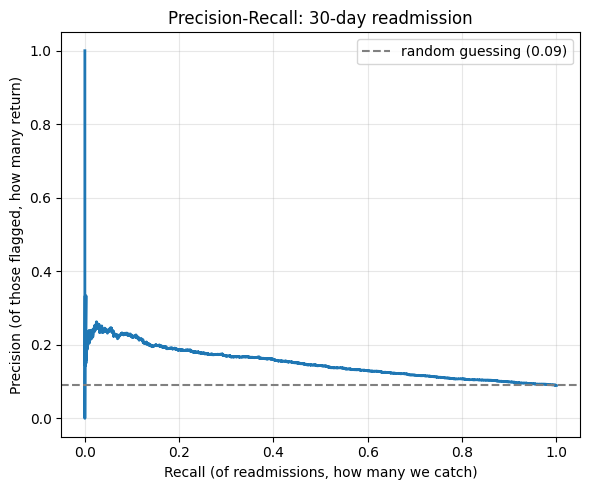

In [32]:
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, proba)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, linewidth=2)
plt.axhline(y_test.mean(), linestyle='--', color='grey',
            label=f'random guessing ({y_test.mean():.2f})')
plt.xlabel('Recall (of readmissions, how many we catch)')
plt.ylabel('Precision (of those flagged, how many return)')
plt.title('Precision-Recall: 30-day readmission')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()

In [33]:
import shap

X_test_transformed = best_model.named_steps['pre'].transform(X_test)

# Recover feature names after one-hot encoding
num_names = NUMERIC
cat_names = (best_model.named_steps['pre']
             .named_transformers_['cat']
             .get_feature_names_out(CATEGORICAL).tolist())
feature_names = num_names + cat_names

X_shap = pd.DataFrame(np.asarray(X_test_transformed), columns=feature_names)
print(f"Explaining {X_shap.shape[0]:,} patients "
      f"across {X_shap.shape[1]} features")

# TreeExplainer is the fast exact method for tree models
explainer = shap.TreeExplainer(best_model.named_steps['clf'])
shap_values = explainer.shap_values(X_shap)
print("SHAP values computed")

Explaining 13,994 patients across 62 features
SHAP values computed


In [34]:
# mean absolute SHAP = how much this feature moves predictions overall
importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("TOP 10 DRIVERS OF 30-DAY READMISSION RISK\n")
for i, row in importance.head(10).iterrows():
    idx = feature_names.index(row['feature'])
    # Correlation between the feature value and its SHAP value
    # tells us the DIRECTION of the effect
    corr = np.corrcoef(X_shap[row['feature']], shap_values[:, idx])[0, 1]
    direction = "raises risk" if corr > 0 else "lowers risk"
    print(f"{i+1:2d}. {row['feature']:<34} "
          f"{row['mean_abs_shap']:.4f}  ({direction})")

TOP 10 DRIVERS OF 30-DAY READMISSION RISK

 1. discharge_group_TransferFacility   0.3235  (raises risk)
 2. age_midpoint                       0.2478  (raises risk)
 3. gender_Male                        0.1920  (raises risk)
 4. num_procedures                     0.1518  (lowers risk)
 5. time_in_hospital                   0.1518  (raises risk)
 6. race_Caucasian                     0.1338  (raises risk)
 7. number_diagnoses                   0.1250  (raises risk)
 8. specialty_group_Missing            0.1212  (raises risk)
 9. num_active_diabetes_meds           0.1149  (raises risk)
10. diag1_group_Respiratory            0.0781  (lowers risk)


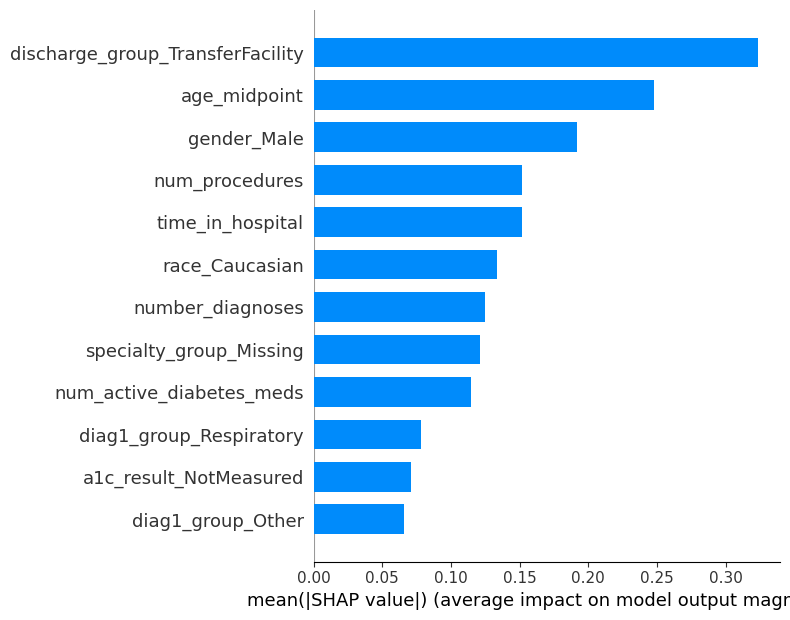

Saved: shap_importance_bar.png


In [39]:
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: shap_importance_bar.png")

In [42]:
import os

# Save the CSVs
summary.to_csv('model_comparison.csv', index=False)
sweep.to_csv('threshold_sweep.csv', index=False)
importance.to_csv('shap_feature_importance.csv', index=False)

print("Files ready to download (folder icon, left sidebar):\n")

expected_files = [
    'model_comparison.csv',
    'threshold_sweep.csv',
    'shap_feature_importance.csv',
    'shap_importance_bar.png',
    'precision_recall_curve.png',
]

for f in expected_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  OK   {f}  ({size_kb:.0f} KB)")
    else:
        print(f"  MISSING   {f}  <- run the cell that creates this first")

Files ready to download (folder icon, left sidebar):

  OK   model_comparison.csv  (0 KB)
  OK   threshold_sweep.csv  (1 KB)
  OK   shap_feature_importance.csv  (2 KB)
  OK   shap_importance_bar.png  (87 KB)
  OK   precision_recall_curve.png  (55 KB)
